In [1]:
# importamos librerías
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score

# Configuración visual
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# EDA

In [3]:
# descriptivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [4]:
df.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6970,6971,15761286,Fan,696,Germany,Female,66,7,119499.42,2,1,1,174027.30,0
7250,7251,15631451,Grant,604,Spain,Female,28,6,0.00,2,1,1,69056.26,0
2290,2291,15674880,Archer,658,Spain,Male,50,2,0.00,2,1,0,52137.73,0
5775,5776,15717527,Ifeanacho,619,France,Female,49,9,145359.99,1,1,0,38186.85,0
40,41,15619360,Hsiao,472,Spain,Male,40,4,0.00,1,1,0,70154.22,0
1922,1923,15805637,Hsing,625,France,Male,36,9,108546.16,3,1,0,133807.77,1
2482,2483,15672610,Somadina,567,Spain,Male,40,4,118628.80,1,0,0,91973.63,0
177,178,15790355,Okechukwu,606,Germany,Male,36,5,190479.48,2,0,0,179351.89,0
4261,4262,15607278,Romano,794,Spain,Female,46,8,134593.79,1,1,1,46386.37,0
3635,3636,15571689,Kelechi,740,France,Female,37,5,0.00,2,1,1,27528.40,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


Separamos datos categóricos de numéricos

In [6]:
# columnas categóricas
categorical_cols = df.select_dtypes(
    include=["str", "category", "bool"]
).columns.tolist()

categorical_cols

['Surname', 'Geography', 'Gender']

In [7]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_cols

['RowNumber',
 'CustomerId',
 'CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [8]:
#Exluimos 2 que no sirven para los histogramas
num_excluir = ["RowNumber", "CustomerId"]
numeric_cols = [col for col in numeric_cols if col not in num_excluir]

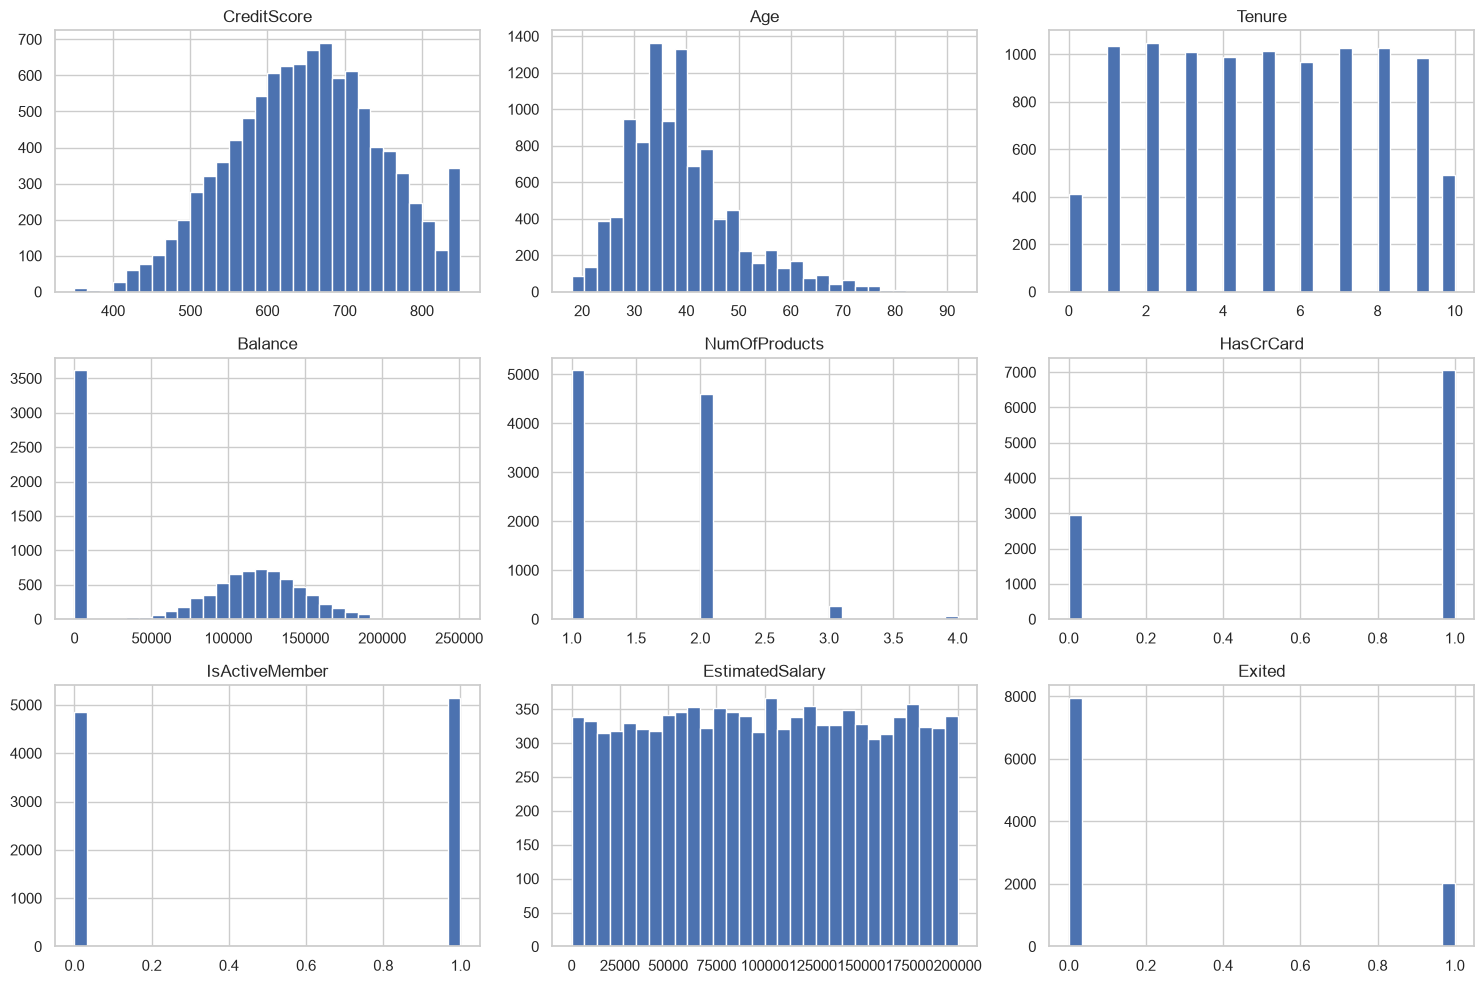

In [9]:
df[numeric_cols].hist(
    figsize=[15,10],
    bins=30
)
plt.tight_layout()
plt.show()

#### Observaciones básicas de las columnas numéricas
* El rango de edad más común de los clientes está entre 35 y 40 años.
* Hay una distribución pareja entre los años de antigüedad (Tenure), aunque hay una pequeña cantidad que tiene 10 años. 
* Un gran porcentaje de los clientes tiene su balance en 0. Puede significar que no usan el banco como caja de ahorro.
* La mayoría tiene entre 1 y 2 productos. Muy pocos 3 o 4.
* El 70% sí tiene tarjeta de crédito.
* (hay que revisar qué implica que sea Active) Casi se divide entre mitad y mitad entre miembros activos y no activos. 
* El salario no tiene grandes diferencias. 
* El 80% no abandonó. El 20% sí. 

## Tratamiento de valores faltantes básico

### Nulos

In [10]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

No hay valores nulos. 

### Duplicados

Verificamos que no haya duplicados en los ID de los clientes, ya que solo necesitamos una fila por cliente

In [11]:
df.duplicated('CustomerId').sum()

np.int64(0)

No existen duplicados del ID de las personas, por tanto, cada fila es de una persona distinta

### Errores
Verificamos datos que no sean adecuados, para eliminarlos o imputarlos. Por ejemplo si los valores que deberían ser 0 o 1 tienen otros valores. 

In [12]:
display(df['HasCrCard'].unique()) 
display(df['IsActiveMember'].unique()) 
display(df['Exited'].unique()) 


array([1, 0])

array([1, 0])

array([1, 0])

Todos tienen valores correctos (entre sí 1 y no 0)

### Desbalanceo de clases
Analizar qué porcentaje del total han abandonado el banco.

In [13]:
df["Exited"].value_counts(1)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

Hay una gran diferencia, prácticamente un 80% no ha dejado el banco. Hay que tener en cuenta esto al entrenar el modelo. 

## Exploraciones básicas

### Variables demográficas

#### Género

In [14]:
# por género
df.groupby("Gender")["Exited"].value_counts(normalize=True).unstack() * 100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


El 25% de mujeres ha salido del banco. Mientras que solo el 16% de los hombres. En general la proporcion es 80/20, pero viendo más de cerca analizando por sexo, hay algunas diferencias. 

#### País

In [15]:
# por ciudad
df.groupby("Geography")["Exited"].value_counts(normalize=True).unstack() * 100

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


En España y Francia se da que solo un 16% deja el banco, mientras que en Alemania se da el doble. Un 32% deja el banco. Esto llama la atención. ¿Qué está pasando en Alemania?

#### Número de productos

In [16]:
df.groupby("NumOfProducts")["Exited"].value_counts(normalize=True).unstack() * 100

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,NaN,100.000000


Interesante: los clientes más fieles son los que tienen entre 1 y 2 productos. De los que tienen 3 productos, un 82,% abandonan. Curiosamente de los que tienen 4 productos no queda uno.

#### Edad

<Axes: title={'center': 'Porcentaje de churn según cada grupo etario'}, ylabel='AgeGroup'>

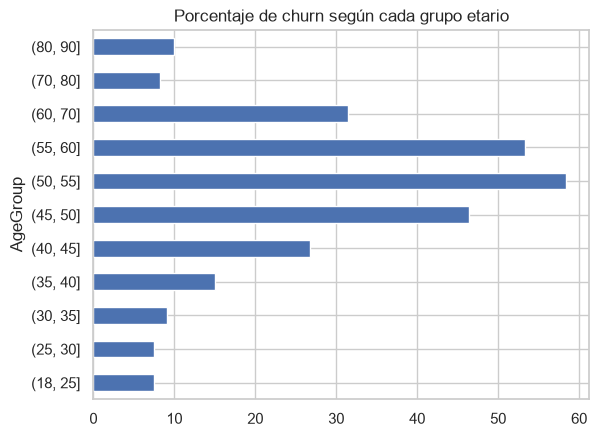

In [17]:
#age_range = range(min(df["Age"]), max(df["Age"]), 10)
age_range = (18,25,30,35,40,45,50,55,60,70,80,90)
      
df["AgeGroup"] = pd.cut(df["Age"], age_range)
agegroup_table = df.groupby("AgeGroup")["Exited"].value_counts(normalize=True).unstack() * 100

agegroup_table[1].plot(kind="barh", title="Porcentaje de churn según cada grupo etario")

In [18]:
agegroup_table

Exited,0,1
AgeGroup,,
"(18, 25]",92.529711,7.470289
"(25, 30]",92.483419,7.516581
"(30, 35]",90.892449,9.107551
"(35, 40]",85.039718,14.960282
"(40, 45]",73.197279,26.802721
"(45, 50]",53.647059,46.352941
"(50, 55]",41.648590,58.351410
"(55, 60]",46.726190,53.273810
"(60, 70]",68.580060,31.419940


El rango de edad con más tasa de Churn está entre los 50 y 55 años, con casi el 60% de las personas entre estas edades dejando el banco

#### Credit Score
¿Hay correlación entre cierto CS y los que se van?

<Axes: title={'center': 'Porcentaje de churn según Credit Score'}, ylabel='CreditScoreRange'>

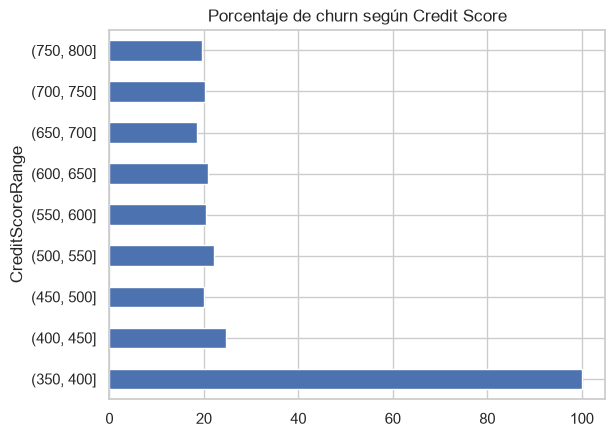

In [19]:
cs_range = range(min(df["CreditScore"]), max(df["CreditScore"]), 50)
      
df["CreditScoreRange"] = pd.cut(df["CreditScore"], cs_range)
csrange_table = df.groupby("CreditScoreRange")["Exited"].value_counts(normalize=True).unstack() * 100
csrange_table[1].plot(kind="barh", title="Porcentaje de churn según Credit Score")

#### Correlaciones varias

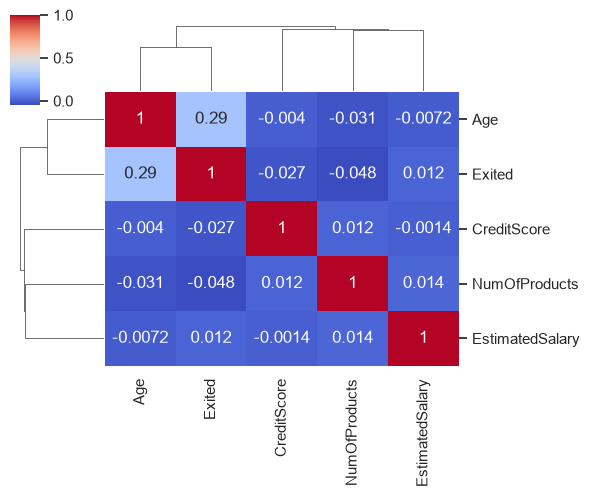

In [20]:
variables_interes = ['Age', 'NumOfProducts', 'EstimatedSalary', 'Exited', 'CreditScore']
df_vars = df[variables_interes]
corr = df_vars.corr()
# Armamos mapa de calor con SeaBorn
sns.clustermap(corr, annot=True, figsize=(6,5), cmap='coolwarm')
plt.show()

No hay ninguna correlación relevante con estas variables. No hay multicolinealidad

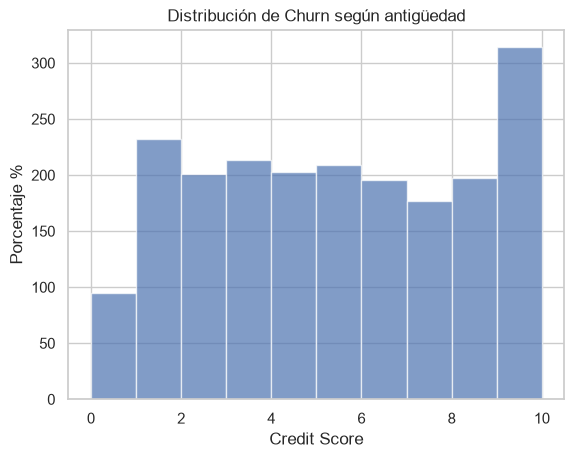

In [21]:
data = df[df['Exited']==1]['Tenure']
data.hist(alpha=0.7, label='Se fue', bins=10) # evaluamos con histograma
plt.xlabel('Credit Score')
plt.ylabel('Porcentaje %')
plt.title('Distribución de Churn según antigüedad')
plt.show()

# Preparación de datos para regresión logística

## Encoding
### Dividir el dataset en train y test

In [22]:
# seleccionamos primero solo las columnas que nos van a servir más
subset = [
'CreditScore', 'Geography',
       'Gender', 'Age', 'AgeGroup', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'
]

In [23]:
# definimos las features y el target
X = df[subset] # features
y = df['Exited'] # target

In [24]:
# dividimos en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # qué porcentaje del dataset destinaremos para testear
    random_state=42,
    stratify=y              # la variable objetivo, que es Exited
)

print("X_train:", X_train.shape)
print(y_train.value_counts(1))

print("X_test:", X_test.shape)
print(y_test.value_counts(1))


X_train: (8000, 11)
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64
X_test: (2000, 11)
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


### Preprocesamiento

Volvamos a establecer las variables categóricas y las numéricas

In [25]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'AgeGroup',
       'CreditScoreRange'],
      dtype='str')

In [ ]:
numeric_cols = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]

categorical_cols = [
    'Geography',
    'Gender',
    'HasCrCard',
    'IsActiveMember',
]

#### Imputación de variables numéricas y categóricas

In [27]:
pipeline_numeric = Pipeline(
    [
        ('imputter', SimpleImputer(strategy='median')),
        ('transform', StandardScaler())
    ]
)

pipeline_categorical = Pipeline(
    [
        ('imputter', SimpleImputer(strategy='most_frequent')),
        ('transform', OneHotEncoder(handle_unknown='ignore', min_frequency=0.05, sparse_output=False))
    ]
)
pipeline_numeric

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputter', ...), ('transform', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto accoun

In [28]:
ct = ColumnTransformer(
    [
        ("preprocessor_num", pipeline_numeric, numeric_cols),
        ("preprocessor_cat", pipeline_categorical, categorical_cols)
    ]
)
ct

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('preprocessor_num', ...), ('preprocessor_cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_n

In [29]:
from sklearn.feature_selection import SelectKBest, f_classif

fs = SelectKBest(
    f_classif,
    k=4
)
# es otro Pipeline para contener los otros pipelines

preprocessor_fs = Pipeline(
    [
        ("preprocessor", ct),
        ("feature_selection", fs)
    ]
)

preprocessor_fs

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('preprocessor_num', ...), ('preprocessor_cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold spar

# Entrenar un modelo

## LogisticRegression

In [ ]:
# crear el modelo
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced',
)

lr_pipeline = Pipeline(
    [
        ("preprocessor_fs", preprocessor_fs),
        ("model", logistic_model)
    ]
)


In [31]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor_fs', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['CreditScore','Geography','Gender',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to 

## DecisionTreeClassifier

In [32]:
# crear el modelo
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_leaf=0.05,
    class_weight='balanced',
)

dt_pipeline = Pipeline(
    [
        ("preprocessor_fs", preprocessor_fs),
        ("model", dt_model)
    ]
)

In [33]:
dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor_fs', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['CreditScore','Geography','Gender',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to 

# Generar predicciones

In [34]:
y_train_log_pred = lr_pipeline.predict(X_train)
y_test_log_pred = lr_pipeline.predict(X_test)
y_test_log_proba = lr_pipeline.predict_proba(X_test)[:,1] # le digo que solo me interesa las probabilidades de "1", de que haya Exited.

y_train_dt_pred = dt_pipeline.predict(X_train)
y_test_dt_pred = dt_pipeline.predict(X_test)
y_test_dt_proba = dt_pipeline.predict_proba(X_test)[:,1] 

# Evaluar los modelos
Usaremos f1_score para evaluar la precisión del modelo al generar predicciones. 


In [35]:
# logistic
train_f1_log = f1_score(y_train, y_train_log_pred)
test_f1_log = f1_score(y_test, y_test_log_pred)

print(f"Train set, using Logistic Regression has a F1 Score of: {train_f1_log:.3f}")
print(f"Test set, using Logistic Regression has a F1 Score of:  {test_f1_log:.3f}")

# decision tree
train_f1_dt = f1_score(y_train, y_train_dt_pred)
test_f1_dt = f1_score(y_test, y_test_dt_pred)

print(f"Train set, using Decision Tree has a F1 Score of: {train_f1_dt:.3f}")
print(f"Test set, using Decision Tree has a F1 Score of:  {test_f1_dt:.3f}")

Train set, using Logistic Regression has a F1 Score of: 0.488
Test set, using Logistic Regression has a F1 Score of:  0.507
Train set, using Decision Tree has a F1 Score of: 0.518
Test set, using Decision Tree has a F1 Score of:  0.515


In [36]:
# hacemos el gráfico
pd.Series(
    logistic_model.coef_[0],
    index = 4
).sort_values().plot(kind='barh')

TypeError: Index(...) must be called with a collection of some kind, 4 was passed

In [ ]:
# hacemos el gráfico
pd.Series(
    dt_model.coef_[0],
    index = 4
).sort_values().plot(kind='barh')

Según esto, lo que más influencia tiene en la tasa de Churn es la edad. 

# Apartado: Probamos con otro modelo

## Decision Tree

In [ ]:
# DecisionTree
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_leaf=0.05,
    class_weight='balanced'
)

dt.fit(X_train_trans, y_train)

In [ ]:
y_train_dt_pred = dt.predict(X_train_trans)
y_test_dt_pred = dt.predict(X_test_trans)
y_test_dt_proba = dt.predict_proba(X_test_trans)[:  , 1]

In [ ]:
# Evaluamos el modelo Decision Tree ahora
train_f1_dt = f1_score(y_train, y_train_dt_pred)
test_f1_dt = f1_score(y_test, y_test_dt_pred)

print(f"Train f1 dt: {train_f1_dt:.3f}")
print(f"Test f1 dt:  {test_f1_dt:.3f}")

In [ ]:
pd.Series(
    dt.feature_importances_,
    index = X_train_trans.columns
).sort_values().plot(kind='barh')

---

In [ ]:
df.columns.tolist()

In [ ]:
df.sample(10)